<h1 style="color:#1C2951;">Data Visualization & EDA Tutorial with Seaborn and Matplotlib</h1>
<h3>Using the <strong>Titanic</strong> dataset available from:</h3>
<p><i><strong>Dataset citation</strong><br>
Will Cukierski. Titanic - Machine Learning from Disaster. https://kaggle.com/competitions/titanic, 2012. Kaggle.</i></p>
<p><strong>Notebook author</strong><br>Melanie King</p>
<div style="padding:0.5em 1em;background-color:#FDEFB2;font-size:1.1em;">
<h4>ML Objective:</h4>
<p>To predict if a passenger survived the sinking of the Titanic or not. For each in the test set, you must predict a 0 or 1 value for the variable. Your score is the percentage of passengers you correctly predict. This is known as <strong><i>accuracy</i></strong>.</p>
<h4>Tutorial Objectives:</h4>
<ol>
<li>Show how to load and explore data.</li>
<li>Practice detecting missing values and outliers.</li>
<li>Visualize distributions and relationships between features.</li>
<li>Provide discussion questions to spark critical thinking.</li>
</ol>
</div>

<div style="background:#1C2951;color:white;font-size:1.6em;padding:0.2em;font-weight:bold;">STEP 1: Import Libraries and set-up</div>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Set a theme for Seaborn plots
sns.set_theme(style="whitegrid")

<div style="background:#1C2951;color:white;font-size:1.6em;padding:0.2em;font-weight:bold;">STEP 2: Load the dataset</div>
<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<p>We'll load the Kaggle Titanic dataset from a local CSV. Make sure you have 'titanic_train.csv' in a folder called 'datasets'. The dataset includes passenger attributes (age, sex, class, etc.) and whether they survived (survived=1) or not (survived=0).</p>
<table style="text-align:left;">
    <caption style="text-align:left;font-size:1.2em;font-weight:bold;background-color:white;padding:0.2em;border-bottom:1px dashed;">Data Dictionary</caption>
<tr><th>Variable</th><th>Definition</th></tr>
    <tr><td>survival</td><td>Survival (0=No, 1=Yes)</td></tr>
    <tr><td>pclass</td><td>Ticket Class (1=1st, 2=2nd, 3=3rd)</td></tr>
    <tr><td>sex</td><td>Sex</td></tr>
    <tr><td>Age</td><td>Age in years</td></tr>
    <tr><td>sibsp</td><td>Number of siblings / spouses aboard the Titantic</td></tr>
    <tr><td>parch</td><td>Number of parents / children aboard the Titanic</td></tr>
    <tr><td>ticket</td><td>Ticket number</td></tr>
    <tr><td>fare</td><td>Passenger fare</td></tr>
    <tr><td>cabin</td><td>Cabin number</td></tr>
    <tr><td>embarked</td><td>Port of embarkation (C=Cherbourg, Q=Queenstown, S=Southampton)</td></tr>
</table>
</div>

In [2]:
#titanic = sns.load_dataset('titanic')
titanic = pd.read_csv("datasets/titanic_train.csv")

# Check the first few rows
print("\n--- Titanic Data (first 5 rows) ---")
titanic.head(5)


--- Titanic Data (first 5 rows) ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check other interesting bits about the dataset
print("\n--- Titanic Data (INFO) ---")
titanic.info()


--- Titanic Data (INFO) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<div style="background:#1C2951;color:white;font-size:1.6em;padding:0.2em;font-weight:bold;">STEP 3: Investigate and handle missing data</div>
<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<ul>
<li>Q1: Which columns have missing data?</li>
<li>Q2: Why might some columns be missing data, and how could that impact analysis?</li>
<li>Q3: What is a good strategy for handling missing data?</li>
</ul>
</div>


In [4]:
missing_counts = titanic.isnull().sum()
print("\n--- Missing Values in Each Column ---")
print(missing_counts)


--- Missing Values in Each Column ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


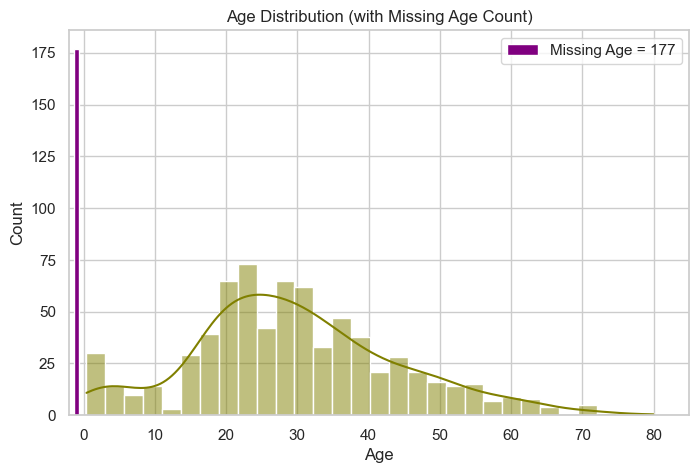

In [5]:
# 1) Fill missing cabins with 'Unknown'
titanic['Cabin'] = titanic['Cabin'].fillna('Unknown')

# 2 ) Plot a histogram of age and include visualisation of number of null counts
null_count = titanic['Age'].isnull().sum()
plt.figure(figsize=(8,5))
sns.histplot(data=titanic, x='Age', bins=30, kde=True, color='olive')
plt.title("Age Distribution (with Missing Age Count)")
plt.xlabel("Age")
plt.ylabel("Count")

# 3) Plot an orange bar at x = -1, representing how many are null
#    We'll use a standard Matplotlib bar(...) call on top of the Seaborn plot
plt.bar(
    -1,                  # x-coordinate of the bar
    null_count,          # height of the bar = number of missing ages
    width=0.8,           # bar thickness
    color='purple',
    label=f"Missing Age = {null_count}"
)

# 4) Adjust x-limits so the -1 bar is visible
#    We'll set the left limit to -2, and the right limit to something
#    slightly larger than the max Age you expect, for aesthetics.
plt.xlim(-2, 85)

# 5) Add a legend so we can see the label for the orange bar
plt.legend()
plt.show()

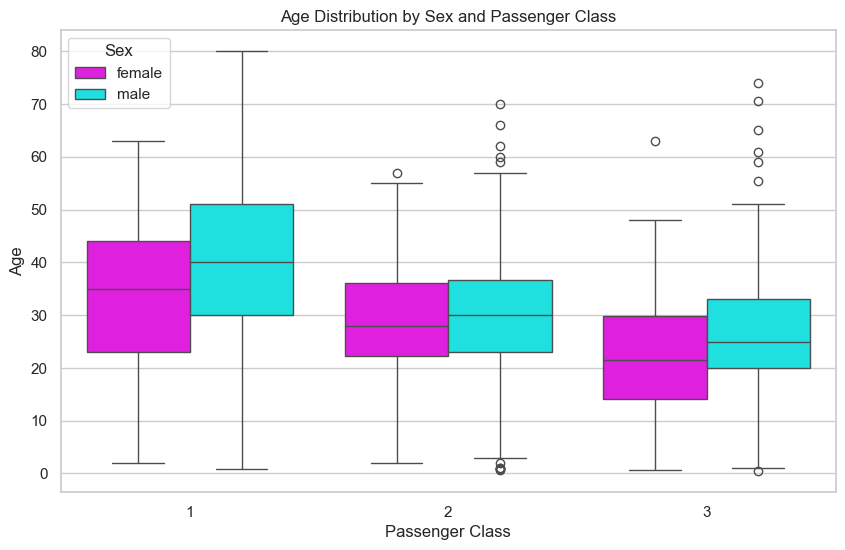

In [6]:
# 3) Visualize Age distribution by Sex and Pclass
plt.figure(figsize=(10,6))
sns.boxplot(data=titanic, x='Pclass', y='Age', hue='Sex', palette={'male': 'cyan', 'female': 'magenta'})
plt.title("Age Distribution by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
    <p>Possible Approaches for Age Imputation:</p>
<ul>
    <li>Simple median: age_median = titanic['Age'].median()</li>
<li>Group-based median: Use titanic.groupby(['Pclass','Sex'])['Age'].transform('median')</li>
<li>More sophisticated model-based approach.</li>
</ul>
<p>Our approach to filling missing age data:</br><i><strong>Using group-based median to fill missing age</i></strong></p>
</div>

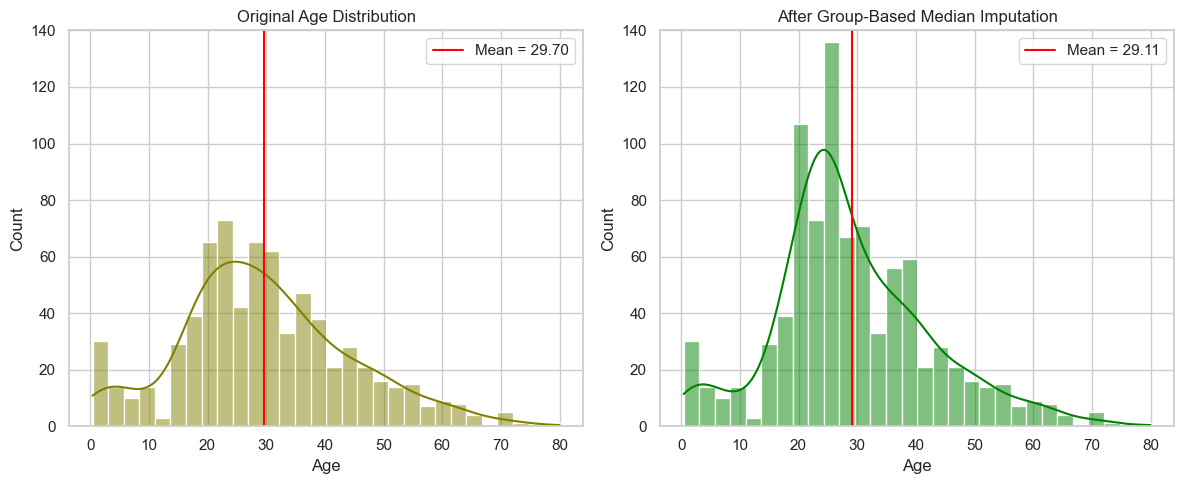

In [7]:
# Make a copy of the original Titanic DataFrame
titanic_imputed = titanic.copy()

# Suppose we do group-based median imputation for Age (by Pclass, Sex)
group_median_age = titanic_imputed.groupby(['Pclass','Sex'])['Age'].transform('median')
titanic_imputed['Age'] = titanic_imputed['Age'].fillna(group_median_age)

# Calculate means for each dataset (ignoring NaN by default)
mean_original = titanic['Age'].mean()
mean_imputed = titanic_imputed['Age'].mean()

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --------------------------------------------------------------------------------
# Original distribution
# --------------------------------------------------------------------------------
sns.histplot(data=titanic, x='Age', bins=30, kde=True, color='olive', ax=axes[0])
axes[0].set_title("Original Age Distribution")
axes[0].set_ylim(0, 140)  # keep y-axis consistent

# Add an orange vertical line for the mean Age (original)
axes[0].axvline(mean_original, color='red', label=f"Mean = {mean_original:.2f}")
axes[0].legend()

# --------------------------------------------------------------------------------
# After imputation
# --------------------------------------------------------------------------------
sns.histplot(data=titanic_imputed, x='Age', bins=30, kde=True, color='green', ax=axes[1])
axes[1].set_title("After Group-Based Median Imputation")
axes[1].set_ylim(0, 140)  # match y-axis limit

# Add an orange vertical line for the mean Age (imputed)
axes[1].axvline(mean_imputed, color='red', label=f"Mean = {mean_imputed:.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()


<div style="background:#1C2951;color:white;font-size:1.6em;padding:0.2em;font-weight:bold;">Step 4: Explore Relationships Between Existing Features and UNUSUAL Data Points</div>
<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<p><strong><i>“Which group is most likely to survive?”</i></strong> We can really think about the real-world nature of this information, rather than rush straight to visualising all sorts of mathematical relationships.</p>
</div>

<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<h3 style="color:#1C2951;">Step 4.1 Relationship Between Categorical Features (Sex vs. Survived)</h3>
<p><strong>Why:</strong> We often want to see whether male/female passengers had different survival outcomes.</p></div>

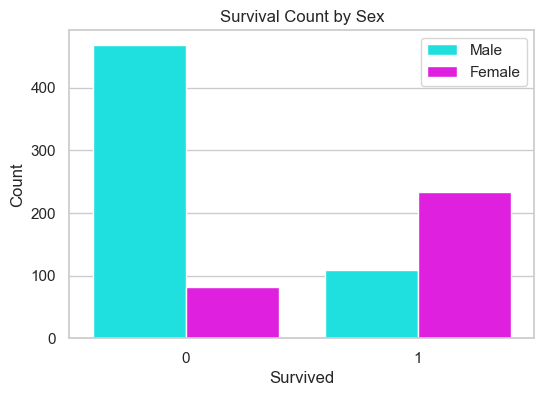

In [8]:
# Countplot of 'Sex' vs. 'Survived'
plt.figure(figsize=(6,4))
sns.countplot(
    data=titanic_imputed,
    x='Survived',        # the bars will be for Died vs. Survived
    hue='Sex',           # color by male or female
    palette={'male': 'cyan', 'female': 'magenta'}
)
plt.title("Survival Count by Sex")
plt.xlabel("Survived")   # 0 = Died, 1 = Survived
plt.ylabel("Count")
plt.legend(labels=["Male","Female"])
plt.show()

<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<h3 style="color:#1C2951;">Step 4.2 Relationship Between Categorical and Numeric Features (Pclass vs. Fare)</h3>
<p><strong>Why:</strong> Passengerclass might correlate with ticket price. We can use a box plot or a strip plot.</p></div>

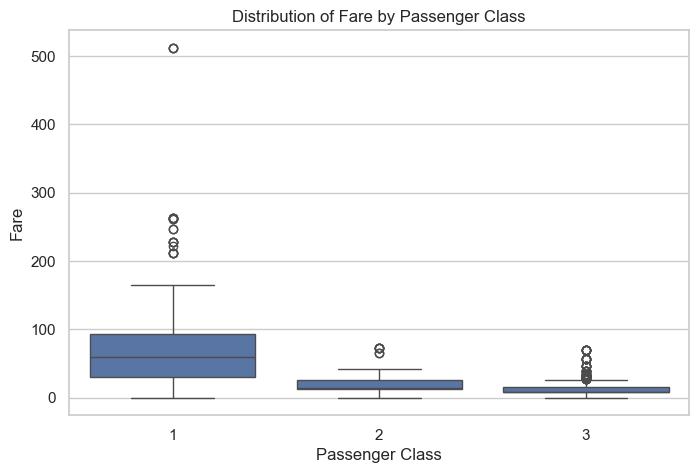

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=titanic_imputed, x='Pclass', y='Fare')
plt.title("Distribution of Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

<div style="color:green;">
<p><strong>Note:</strong> Can you see the unusual data point of a very high price far in class 1? It’s likely an outlier in terms of statistical distribution, but not necessarily an error—some first-class tickets were extremely expensive, sometimes covering multiple passengers or a larger set of cabin accommodations. Here are common approaches to decide how (or if) to handle it:</p>
<ol>
<li><strong>Verify the Data</strong> - Investigate the Passenger Record: Check if the fare is correct. Maybe the ticket included multiple people or multiple legs of travel. Historical Context: High-value tickets did exist, so it might be valid rather than a data-entry mistake.
</li>
<li><strong>Apply an Outlier Treatment</strong> (If You Deem It Necessary)
    <ul>
    <li>Keep It As Is - If this point is valid and you have no reason to believe it’s an error, you may choose to keep the data.
        Pros: Preserves real extremes that may be relevant to modeling or analysis.
        Cons: Can skew certain statistics (like mean, scale in your plots).</li>
    <li>Transform the Fare (e.g., Log Transform)
        Logarithmic or another nonlinear transformation can reduce the impact of very high fares.
        Pros: Often helps if you plan to use linear models, as it stabilizes variance and normalizes distribution.
        Cons: Interpretation of the log scale can be less intuitive for students at first.</li>
    <li>Truncate / Winsorize - Replace extreme values above a chosen percentile (e.g., 99th) with that percentile’s value.
        Pros: Minimizes the effect of outliers without discarding data entirely.
        Cons: Some domain knowledge is needed to decide a cutoff. Potentially hides real phenomena if the outliers are meaningful.</li>
    <li>Remove the Outlier - Pros: Simplifies distribution if the data point is likely erroneous.
        Cons: You lose real data that might matter for your analysis or for a realistic scenario.</li>
    </ul>
</li>
</ol></div>

<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<h3 style="color:#1C2951;">Step 4.3 Relationship Between Two Categorical Features (Pclass vs. Sex, Colored by Survived)</h3>
<p><strong>Why:</strong> Sometimes you want to see two categorical features simultaneously. For example, “How do Passenger Class and Sex interplay with survival?”</p></div>

Text(0.5, 1.05, 'Survival by Pclass and Sex')

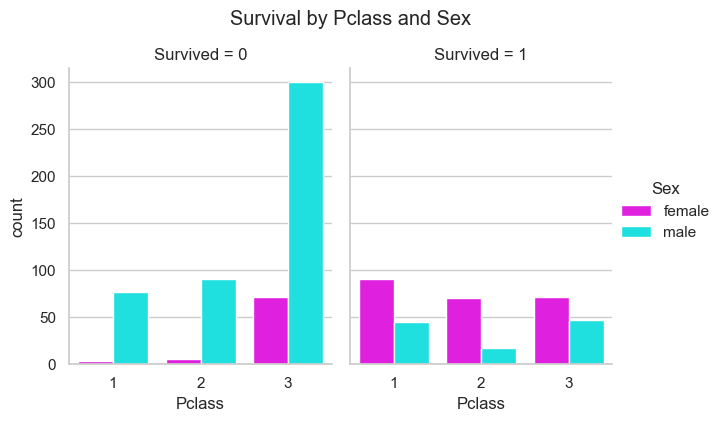

In [10]:
# this is using seaborn
g = sns.catplot(data=titanic_imputed, x='Pclass', 
                hue='Sex', col='Survived', kind='count', 
                height=4, aspect=0.8 , 
                palette={'male': 'cyan', 'female': 'magenta'})
g.fig.suptitle("Survival by Pclass and Sex", y=1.05)

<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<h3 style="color:#1C2951;">Step 4.4 Relationship Between Two Numeric Features (Age vs. Fare)</h3>
<p><strong>Why:</strong> Understand if older passengers paid more or less, or if it’s just random.</p></div>

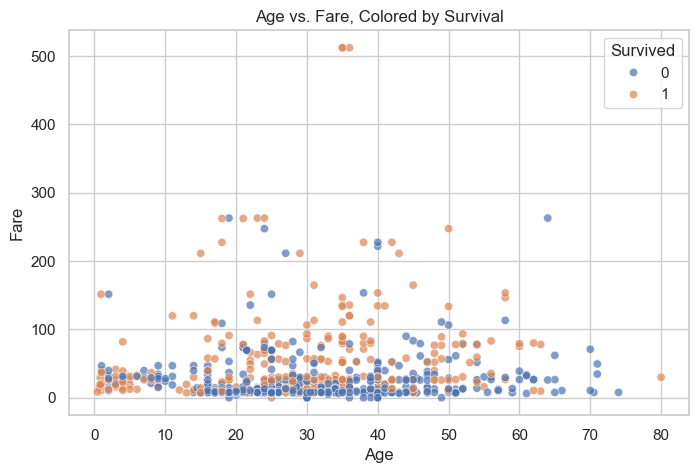

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=titanic_imputed, x='Age', y='Fare', hue='Survived', alpha=0.7)
plt.title("Age vs. Fare, Colored by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<h3 style="color:#1C2951;">Step 4.5 Correlation Matrix (Numeric Features)</h3>
<p><strong>Why:</strong> A correlation matrix shows pairwise correlation (often Pearson’s r) among numeric columns. It answers questions like “Do older passengers pay higher fares?” or “Is Pclass strongly correlated with Fare?”</p></div>

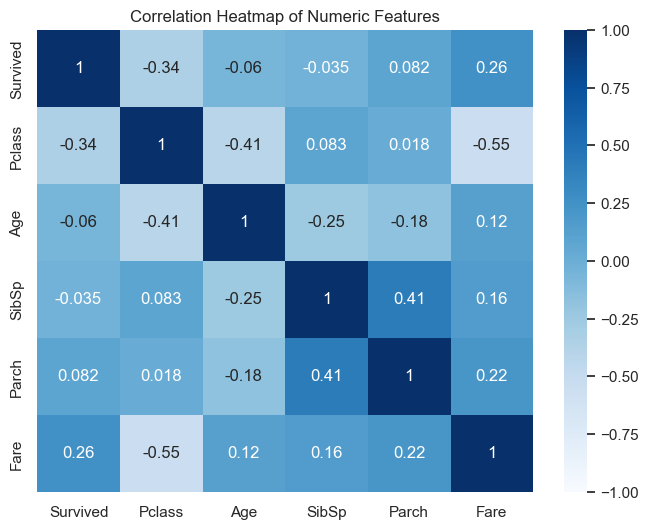

In [12]:
# Select numeric columns (example set)
num_features = ['Survived','Pclass','Age','SibSp','Parch','Fare']

# Compute correlation matrix
corr_matrix = titanic_imputed[num_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

<div style="color:green;">
<p><strong>What Are We Looking At?</strong></p>
<ol>
<li><strong>Diaganol:</strong> Always 1.0 (feature correlated with itself
</li>
<li><strong>Off-Diagonal Cells</strong> Correlation between feature i and feature j.
    <ul>
    <li><strong>Positive correlation</strong> (> 0): As one feature increases, so does the other (e.g., Fare vs. Pclass might be negatively correlated because 1 < 2 < 3 but 1 is “First Class”).</li>
    <li><strong>Negative correlation</strong> (< 0): As one feature increases, the other decreases (e.g., Pclass is typically inversely related to Fare: higher class number means lower cost).</li>
    <li><strong>Magnitude:</strong> Closer to ±1 → stronger linear relationship; around 0 → weaker or no linear correlation.</li>
    </ul>
</li>
</ol></div>

<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<p><strong>What about the correlation of male or female passengers and survival?</strong> When computing a correlation, using one column (0=Female, 1=Male) makes it straightforward to interpret. A positive correlation with Survived means higher survival for the “1” group, a negative correlation means higher survival for the “0” group.</p>
</div>

In [13]:
# If your 'Sex' column is "male"/"female" i.e. as categorical data,
# we can create 'is_male' as a single binary feature.

titanic_imputed['is_male'] = titanic_imputed['Sex'].map({'male': 1, 'female': 0})

# Then you can check correlation with 'Survived'
corr = titanic_imputed[['is_male','Survived']].corr()
print(corr)

           is_male  Survived
is_male   1.000000 -0.543351
Survived -0.543351  1.000000


<div style="color:green;">
<p><strong>Interpretation:</strong> If corr.loc['is_male','Survived'] is a negative number, it suggests being male (1) is associated with lower survival. A positive number would mean being male is associated with higher survival (historically unlikely in the Titanic context).</p></div>

<div style="background:#1C2951;color:white;font-size:1.6em;padding:0.2em;font-weight:bold;">Step 5: Add new features to the dataset</div>
<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<p><strong><i>“Does family size or fare matter?”</i></strong> by adding new features (a.k.a. feature engineering) to the Titanic dataset, then visualizing them to see if any strong correlations or patterns emerge—patterns that might suggest which ML algorithm would handle the data best.</p>
</div>

<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<h3 style="color:#1C2951;">Step 5.1 Create new features</h3></div>

In [14]:
# 1) Family Related Features
# ----------------------------
# [A] FAMILY SIZE
#  Definition: SibSp + Parch + 1 (the passenger themselves).
#  Rationale: Passengers traveling alone vs. large families may have different survival rates.

titanic_imputed['FamilySize'] = titanic_imputed['SibSp'] + titanic_imputed['Parch'] + 1

# [B] IS ALONE
#  Definition: 1 if FamilySize == 1, otherwise 0.
#  Rationale: Does being alone strongly affect survival rates?

titanic_imputed['IsAlone'] = (titanic_imputed['FamilySize'] == 1).astype(int)

# 2) Cabin-related Features
# ----------------------------
# [A] HAS CABIN
# Definition: 1 if Cabin is not 'Unknown' (or not null), else 0.
# Rationale: Passengers with assigned cabins might be more likely first or second class, which can correlate with survival.

titanic_imputed['HasCabin'] = (titanic_imputed['Cabin'] != 'Unknown').astype(int)

# [B] DECK (if cabin is known)
#  Definition: Take the first letter of the cabin, or U if none.
#  Rationale: Sometimes deck location has a subtle relationship with survival (e.g., which deck was flooded first).

titanic_imputed['Deck'] = titanic_imputed['Cabin'].apply(lambda x: x[0] if x != 'Unknown' else 'U')

# 3) Fare-related Features
# ----------------------------
# Definition: np.log1p(titanic['Fare']) (log of Fare + 1).
# Rationale: f Fare is heavily skewed, log-transform helps certain ML algorithms.
# Visible Patterns: Log scale highlights differences among mid-range fares without letting extremely high fares dominate.

titanic_imputed['LogFare'] = np.log1p(titanic_imputed['Fare'])  # log(1 + fare)


<div style="border:1px solid #1C2951;color:#0E4C92;font-size:1.1em;background-color:#DDE8F3;padding:0.5em 0.5em 0 0.5em;">
<h3 style="color:#1C2951;">Step 5.2 Visualise new features</h3></div>

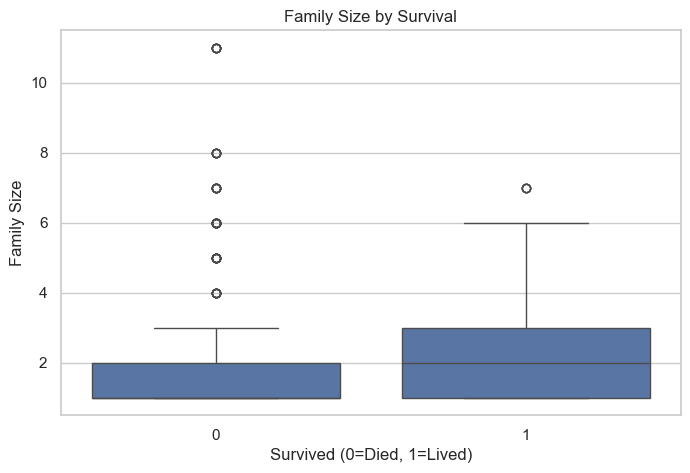

In [15]:
# Box Plot of FamilySize vs. Survived
plt.figure(figsize=(8,5))
sns.boxplot(data=titanic_imputed, x='Survived', y='FamilySize')
plt.title("Family Size by Survival")
plt.xlabel("Survived (0=Died, 1=Lived)")
plt.ylabel("Family Size")
plt.show()


<p style="color:green"><strong>Interpretation:</strong> If survivors tend to have different family sizes than non-survivors, that’s a sign the feature is useful.</p>

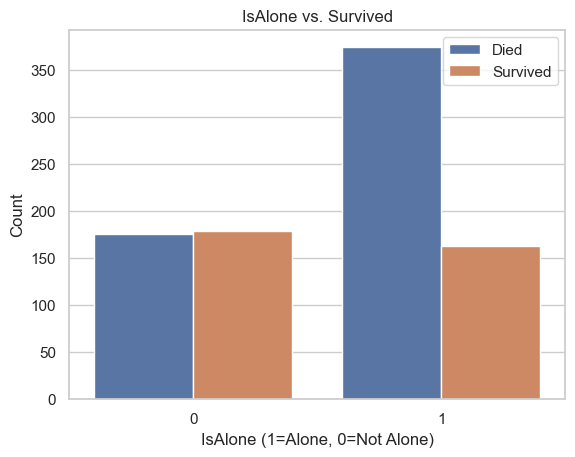

In [16]:
# Count Plot of IsAlone vs. Survived
sns.countplot(data=titanic_imputed, x='IsAlone', hue='Survived')
plt.title("IsAlone vs. Survived")
plt.xlabel("IsAlone (1=Alone, 0=Not Alone)")
plt.ylabel("Count")
plt.legend(labels=["Died","Survived"])
plt.show()

<p style="color:green"><strong>Interpretation:</strong> If being alone leads to a lower or higher survival rate, you’ll see a noticeable difference in the bar heights.</p>

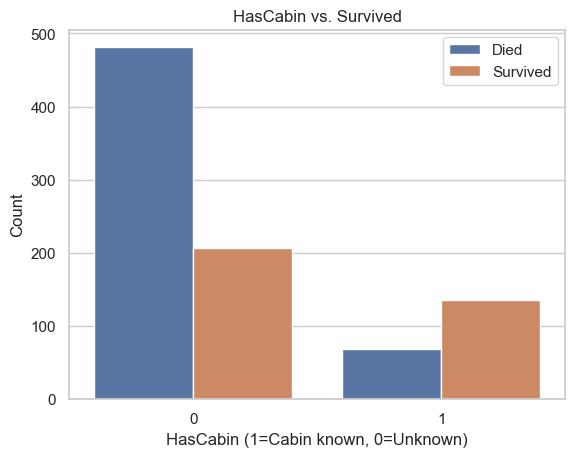

In [17]:
# HasCabin vs. Survived
sns.countplot(data=titanic_imputed, x='HasCabin', hue='Survived')
plt.title("HasCabin vs. Survived")
plt.xlabel("HasCabin (1=Cabin known, 0=Unknown)")
plt.ylabel("Count")
plt.legend(labels=["Died","Survived"])
plt.show()

<p style="color:green"><strong>Interpretation:</strong> If having a known cabin strongly correlates with survival, you’ll see a distinct distribution.</p>

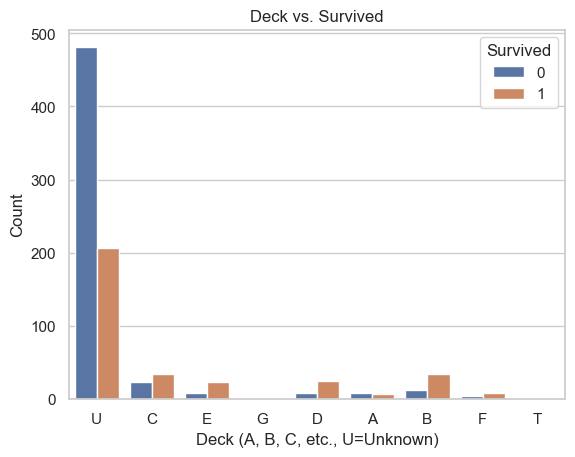

In [18]:
# Deck vs. Survived (If you made a Deck feature)
sns.countplot(data=titanic_imputed, x='Deck', hue='Survived')
plt.title("Deck vs. Survived")
plt.xlabel("Deck (A, B, C, etc., U=Unknown)")
plt.ylabel("Count")
plt.show()

<p style="color:green"><strong>Interpretation:</strong> If certain decks show a higher survival probability, that signals a strong pattern.</p>

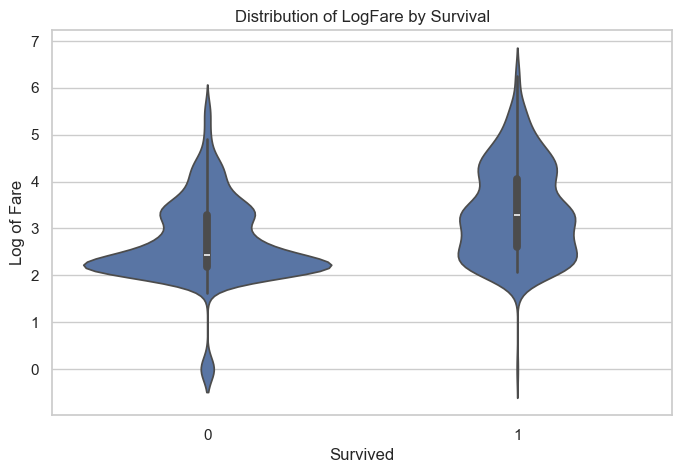

In [19]:
# LogFare vs. Survived (Violin Plot)
plt.figure(figsize=(8,5))
sns.violinplot(data=titanic_imputed, x='Survived', y='LogFare')
plt.title("Distribution of LogFare by Survival")
plt.xlabel("Survived")
plt.ylabel("Log of Fare")
plt.show()

<div style="color:green;">
<p><strong>Interpretation:</strong> A violin plot merges box plot and KDE (kernel density estimate). If higher LogFare is associated with Survived=1, that’s a sign Fare is predictive of survival.</p>
<p>
Each “violin” extends horizontally to show the density of LogFare values for that survival group. Wider sections of the violin = more data points at that LogFare range. Narrower sections = fewer data points. The median is typically shown by a white dot or a horizontal line inside each violin. The quartiles appear as thicker horizontal lines around the center.   
</p>
<p><strong>Example observations:</strong></p>
<ul>
<li>If the survived group’s violin extends higher on average (i.e., they typically have a higher LogFare), it indicates survivors generally paid more (or were from higher-paying classes).</li>
<li>If there is a noticeable difference in median (the white dot or line is higher in the Survived group vs. the Died group), that means the typical (median) log-fare is greater among survivors.</li>
    <li>If the density is quite different (e.g., the Died group has a wide bulge near low fares while the Survived group has a bulge near higher fares), it visually confirms a positive correlation between Fare and the chance of survival.</li>
    </ul>
    <p>If you observe a clear difference (e.g., survivors’ “violin” is generally shifted upward compared to non-survivors), that strongly suggests Fare is a predictive feature—and the log transform is capturing a clearer, less skewed pattern than raw Fare alone.</p>
</div>

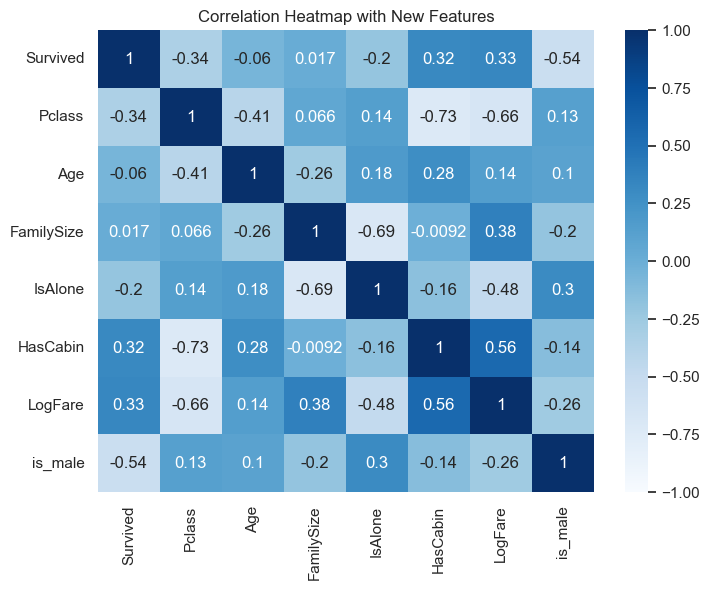

In [20]:
# After adding these columns (FamilySize, IsAlone, HasCabin, LogFare), 
# you can re-run a correlation matrix or pairplot to see if any of these new features strongly correlate with Survived.
new_features = ['Survived','Pclass','Age','FamilySize','IsAlone','HasCabin','LogFare','is_male']
corr_new = titanic_imputed[new_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_new, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title("Correlation Heatmap with New Features")
plt.show()

<p style="color:green"><strong>Interpretation:</strong> Look for features that have a higher absolute correlation with Survived.
If, for example, IsAlone or HasCabin shows a strong correlation (positive or negative) with survival, it’s a sign they might be important inputs for an ML model.</p>

<div style="padding:0.5em 1em;background-color:#FDEFB2;font-size:1.1em;">
<h4>Summary</h4>
<ul>
<li>At the EDA stage, you can do basic correlation checks, domain knowledge analysis, and visual comparisons to guess which features might be important.</li>
<li>However, “true” feature importance arises from model training. The model’s behavior reveals which features most influence predictions—especially in the presence of interactions, non-linearities, or correlated features.</li>
</ul>
<p>Ultimately, EDA is your initial roadmap; ML-based feature importance is the validation of which features actually matter in practice.</p>
</div>

In [21]:
# Save the cleaned DataFrame 'titanic_imputed' to CSV in the "datasets" folder.
# index=False ensures the DataFrame’s index isn’t written as an extra column.
titanic_imputed.to_csv("datasets/titanic_cleaned.csv", index=False)
